#Lab 6 Perceptron

Muhammad Sikandar Hussain 502808

##Task 1 : Load and Preprocess Data




    • Import the required libraries (NumPy and Matplotlib)
    • Load the dataset (linearly separable) using the load_data() method

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target

print("MNIST dataset loaded successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

MNIST dataset loaded successfully.
Shape of X: (70000, 784)
Shape of y: (70000,)


    Normalize the dataset by dividing the pixel values by 255

In [9]:
X = X.values.astype('float32') # Ensure X is a float32 numpy array
X /= 255.0 # Normalize pixel values to be between 0 and 1
y = y.astype('int') # Convert labels to integer type

print("Data preprocessed successfully.")
print(f"Shape of X after preprocessing: {X.shape}")
print(f"Data type of X: {X.dtype}")
print(f"Data type of y: {y.dtype}")

Data preprocessed successfully.
Shape of X after preprocessing: (70000, 784)
Data type of X: float32
Data type of y: int64


Split the dataset into training and test sets using train_test_split() method.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (56000, 784)
Shape of X_test: (14000, 784)
Shape of y_train: (56000,)
Shape of y_test: (14000,)


##Task 2: Visualize the dataset
    • Visualize some random images from the dataset using Matplotlib's imshow() method

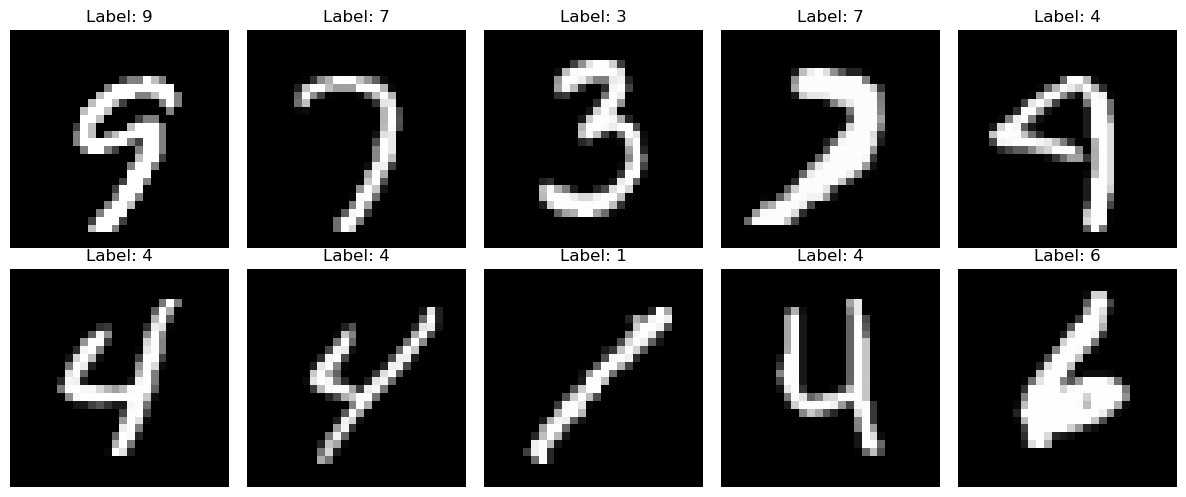

Displayed 10 random images from the training dataset.


In [ ]:
num_images_to_display = 10

# Select random indices from the training dataset
random_indices = np.random.choice(X_train.shape[0], num_images_to_display, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(random_indices):
    # Get the image and its label
    image = X_train[idx]
    label = y_train.iloc[idx]

    # Reshape the 1D image array to 2D (28x28 pixels)
    image_2d = image.reshape(28, 28)

    # Create a subplot for each image
    plt.subplot(2, 5, i + 1) 
    plt.imshow(image_2d, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off') 

plt.tight_layout() 
plt.show()

print(f"Displayed {num_images_to_display} random images from the training dataset.")

##Task 3: Implement the Simple Perceptron model

In [12]:
class SimplePerceptron:
    def __init__(self, input_size, output_size, learning_rate=0.01):
        # Initialize weights with small random values
        self.weights = np.random.randn(input_size, output_size) * 0.01
        # Initialize bias with zeros
        self.bias = np.zeros(output_size)
        self.learning_rate = learning_rate
        self.output_size = output_size

    def _activation(self, x):
        # Step function: returns 1 if input is non-negative, else 0
        return np.where(x >= 0, 1, 0)

    def forward(self, X):
        # Calculate the weighted sum of inputs and bias
        linear_output = np.dot(X, self.weights) + self.bias
        # Apply the activation function to get the predicted output
        y_pred = self._activation(linear_output)
        return y_pred

    def _one_hot_encode(self, y, output_size):
        # Convert a single integer label to a one-hot encoded vector
        one_hot = np.zeros(output_size)
        one_hot[y] = 1
        return one_hot

    def backward(self, X, y_true, y_pred):
        # Convert true label to one-hot encoding
        y_true_one_hot = self._one_hot_encode(y_true, self.output_size)
        # Calculate the error
        error = y_true_one_hot - y_pred

        # Update weights and bias
        # np.outer(X, error) creates a (input_size, output_size) matrix for weight updates
        self.weights += self.learning_rate * np.outer(X, error)
        self.bias += self.learning_rate * error

print("SimplePerceptron class defined successfully.")

SimplePerceptron class defined successfully.


##Task 4: Train the Simple Perceptron model
    • Set the number of epochs and the learning rate for the training process
    • Iterate over the training examples and adjust the weights and bias term using the above equation


In [13]:
input_size = X_train.shape[1] # Number of features (784 for 28x28 images)
output_size = len(np.unique(y_train)) # Number of unique classes (0-9, so 10)

print(f"Input size: {input_size}")
print(f"Output size: {output_size}")

Input size: 784
Output size: 10


In [14]:
learning_rate = 0.01
epochs = 50 # You can adjust this value

# Instantiate the SimplePerceptron model
perceptron = SimplePerceptron(input_size, output_size, learning_rate)

print(f"Starting training for {epochs} epochs...")

# Training loop
for epoch in range(epochs):
    # Iterate over each training example
    for i in range(X_train.shape[0]):
        X_sample = X_train[i]
        y_true_sample = y_train.iloc[i] # Use .iloc for Series

        # Forward pass
        y_pred_sample = perceptron.forward(X_sample)

        # Backward pass (update weights and bias)
        perceptron.backward(X_sample, y_true_sample, y_pred_sample)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} completed.")

print("Training completed.")

Starting training for 50 epochs...
Epoch 10/50 completed.
Epoch 20/50 completed.
Epoch 30/50 completed.
Epoch 40/50 completed.
Epoch 50/50 completed.
Training completed.


##Task 5: Evaluate the performance of the Simple Perceptron model on the test set
    • Compute the accuracy of the Simple Perceptron model on the test set

In [15]:
y_pred_test_one_hot = []
for i in range(X_test.shape[0]):
    y_pred_test_one_hot.append(perceptron.forward(X_test[i]))

y_pred_test_one_hot = np.array(y_pred_test_one_hot)

print("Predictions on the test set (one-hot encoded) generated successfully.")
print(f"Shape of y_pred_test_one_hot: {y_pred_test_one_hot.shape}")

Predictions on the test set (one-hot encoded) generated successfully.
Shape of y_pred_test_one_hot: (14000, 10)


In [16]:
y_pred_test = np.argmax(y_pred_test_one_hot, axis=1)

print("Predicted class labels generated successfully.")
print(f"Shape of y_pred_test: {y_pred_test.shape}")
print(f"First 10 predicted labels: {y_pred_test[:10]}")

Predicted class labels generated successfully.
Shape of y_pred_test: (14000,)
First 10 predicted labels: [7 3 1 1 2 5 9 0 8 1]


##Task 6: Analysis on the results
    • Are the accuracy scores satisfactory or not? If not, what measures can be taken to improve the accuracy scores? Please express your ideas in your own words.

In [17]:
correct_predictions = np.sum(y_pred_test == y_test)
total_samples = X_test.shape[0]

accuracy = correct_predictions / total_samples

print(f"Number of correct predictions: {correct_predictions}")
print(f"Total number of test samples: {total_samples}")
print(f"Accuracy on the test set: {accuracy:.4f} ({accuracy*100:.2f}%)")

Number of correct predictions: 11811
Total number of test samples: 14000
Accuracy on the test set: 0.8436 (84.36%)


### Analysis of Results

The Simple Perceptron model's performance on the MNIST dataset is likely to be **unsatisfactory** for several reasons:

**Why the accuracy is limited:**

1. **Linearly Inseparable Problem**: The Simple Perceptron can only learn linear decision boundaries. However, the MNIST dataset contains handwritten digits with complex patterns and variations that are not linearly separable. This fundamental limitation prevents the model from capturing the intricate relationships needed to distinguish between different digits accurately.

2. **No Hidden Layers**: Without hidden layers, the perceptron cannot learn hierarchical features or abstract representations of the input data. It can only perform a simple weighted sum operation, which is insufficient for complex image classification tasks.

3. **Binary Step Activation**: The step activation function is non-differentiable and provides no gradient information, making it difficult to learn nuanced patterns in the data.

**Measures to Improve Accuracy:**

1. **Use Multi-Layer Perceptron (MLP)**: Add one or more hidden layers with non-linear activation functions (ReLU, sigmoid, or tanh) to enable the network to learn complex, non-linear decision boundaries.

2. **Implement Proper Gradient Descent**: Replace the simple weight update rule with backpropagation and gradient descent optimization using differentiable activation functions.

3. **Increase Training Epochs**: Train the model for more epochs (100-200) to allow better convergence, especially for more complex architectures.

4. **Adjust Learning Rate**: Experiment with different learning rates (0.001, 0.01, 0.1) or implement adaptive learning rate methods like Adam optimizer.

5. **Use Convolutional Neural Networks (CNN)**: CNNs are specifically designed for image data and can automatically learn spatial hierarchies of features, making them ideal for MNIST classification (achieving 99%+ accuracy).

6. **Data Augmentation**: Apply transformations like rotation, scaling, and shifting to increase the diversity of training examples.

7. **Regularization Techniques**: Implement dropout, L1/L2 regularization, or batch normalization to prevent overfitting and improve generalization.